# VoxelGroupClassifier: Smoke Test on S3DIS Scenes
## Entropy-Guided Adaptive Masking for 3D Scene Pretraining

Downloads real S3DIS room data (~3 GB zip from PointNet benchmark), extracts features
from real scene geometry, and tests the VoxelGroupClassifier module end-to-end.

**Data**: [S3DIS HDF5](https://shapenet.cs.stanford.edu/media/indoor3d_sem_seg_hdf5_data.zip) (PointNet prep)

Toggle `USE_REAL_DATA=True/False` for real vs. synthetic quick test.

In [1]:
# ═══════════════════════════════════════
# TOGGLE: use real S3DIS data or synthetic
# ═══════════════════════════════════════
USE_REAL_DATA = True

In [2]:
# ──────── Imports & Setup ────────
import sys, math, os, urllib.request, zipfile, glob, h5py
from collections import defaultdict
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt

# Clone VGC module
!git clone --depth 1 -q https://github.com/yuhang-wang-xjtu/voxel_group_classifier.git /tmp/vgc 2>/dev/null
!cp /tmp/vgc/pointcept/models/sonata/voxel_group_classifier.py ./

from voxel_group_classifier import VoxelGroupClassifier, MaskDiversityScheduler

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if torch.cuda.is_available():
    t = torch.cuda.get_device_properties(0)
    print(f"GPU: {t.name} [{t.total_mem/1e9:.1f} GB]")

# Hparams
D = 384   # feature dim
K = 256   # num groups / prototypes
P3 = 64   # subvoxels per token
M = 256   # tokens (FPS centers)

Device: cpu


## 1. Download S3DIS HDF5 (or synthetic fallback)

Downloads the preprocessed S3DIS dataset from the PointNet benchmark.
This is zip file with 6 HDF5 files (6 areas), ~3 GB.
Each room is 4096-sample blocks with: xyz (3), rgb (3), label (1).

In [5]:
S3DIS_URL  = "https://shapenet.cs.stanford.edu/media/indoor3d_sem_seg_hdf5_data.zip"
S3DIS_URL_MIRROR = "https://huggingface.co/datasets/cminst/S3DIS/resolve/main/indoor3d_sem_seg_hdf5_data.zip"
S3DIS_DIR  = "./indoor3d_sem_seg_hdf5_data"

if USE_REAL_DATA:
    if not os.path.isdir(S3DIS_DIR):
        print("Downloading S3DIS HDF5 (~1.7 GB, ~2 min from HuggingFace)...")
        try:
            urllib.request.urlretrieve(S3DIS_URL_MIRROR, "/tmp/s3dis.zip")
        except Exception:
            print("Mirror failed, trying original...")
            urllib.request.urlretrieve(S3DIS_URL, "/tmp/s3dis.zip")
        with zipfile.ZipFile("/tmp/s3dis.zip") as zf:
            zf.extractall(S3DIS_DIR)
        print(f"Extracted to -> {S3DIS_DIR}")
    else:
        print(f"Already downloaded: {S3DIS_DIR}")

    # List files, searching recursively in case they are in a subdirectory
    h5_files = sorted(glob.glob(f"{S3DIS_DIR}/**/*.h5", recursive=True))
    print(f"\nFound {len(h5_files)} HDF5 files:")
    for f_ in h5_files:
        print(f"  {os.path.basename(f_)}")

    # Load 2 rooms (Area_1, the smallest fold)
    area1 = h5_files[0]  # ply_data_all_0.h5 = Area_1
    with h5py.File(area1, "r") as f:
        data_all = f["data"][:]   # [N_blocks, 4096, 9]
        label_all = f["label"][:]  # [N_blocks, 4096, 1]
        n_blocks = min(len(data_all), 3)
        data_sub = data_all[:n_blocks]   # [3, 4096, 9]
        label_sub = label_all[:n_blocks]  # [3, 4096, 1]
    print(f"\nLoaded {n_blocks} room segments from {os.path.basename(area1)}")
    print(f"  Shape: {data_sub.shape}")
    print(f"  Label classes: {np.unique(label_sub)}")

    # Merge blocks into one scene-like structure
    xyz_all  = data_sub[..., :3].reshape(-1, 3).astype(np.float32)
    rgb_all  = data_sub[..., 3:6].reshape(-1, 3).astype(np.float32)
    lbl_all  = label_sub.reshape(-1).astype(np.int64)

    # Limit total points to avoid Colab OOM
    MAX_PTS = 20000
    if len(xyz_all) > MAX_PTS:
        idx = np.random.RandomState(42).choice(len(xyz_all), MAX_PTS, replace=False)
        xyz_all = xyz_all[idx]
        rgb_all = rgb_all[idx]
        lbl_all = lbl_all[idx]
        print(f"  Downsampled to {len(xyz_all)} pts")

    xyz_t = torch.tensor(xyz_all).to(device)
    rgb_t = torch.tensor(rgb_all).to(device)
    lbl_t = torch.tensor(lbl_all).to(device)

    # FPS -> M center points
    fps_idx = torch.randperm(len(xyz_t), device=device)[:M]
    centers = xyz_t[fps_idx]  # [M, 3]

    # KNN -> P3 nearest neighbors per center
    dists = torch.cdist(centers, xyz_t)  # [M, total_N]
    _, nn_idx = dists.topk(P3, dim=-1, largest=False)  # [M, P3]

    feat_knn = xyz_t[nn_idx]   # [M, P3, 3]
    rgb_knn  = rgb_t[nn_idx]   # [M, P3, 3]
    lbl_knn  = lbl_t[nn_idx]   # [M, P3]

    # Geometric features per patch
    local_xyz = feat_knn - centers.unsqueeze(1)                     # [M, P3, 3]
    centroid  = feat_knn.mean(dim=1, keepdim=True)                  # [M, 1, 3]
    dists_knn = (feat_knn - centroid).norm(dim=-1, keepdim=True)     # [M, P3, 1]

    raw_feat = torch.cat([local_xyz, dists_knn, rgb_knn], dim=-1)   # [M, P3, 7]
    proj = nn.Sequential(
        nn.Linear(7, 128), nn.GELU(), nn.LayerNorm(128), nn.Linear(128, D)
    ).to(device)
    features = F.normalize(proj(raw_feat), dim=-1)

    # Prototypes & teacher sim
    prototypes = F.normalize(torch.randn(K, D, device=device), dim=-1)
    teacher_sim = features @ prototypes.T
    occupancy = torch.ones(M, P3, 1, device=device)

    # Difficulty label: based on label entropy in each patch
    lbl_knn_cpu = lbl_knn.cpu()
    unique_labels_per_patch = []
    for i in range(M):
        unique, counts = np.unique(lbl_knn_cpu[i], return_counts=True)
        probs = counts / counts.sum()
        ent = -np.sum(probs * np.log(probs + 1e-8))
        unique_labels_per_patch.append(ent)
    label_entropy = torch.tensor(unique_labels_per_patch)
    diff_label = torch.zeros(M, dtype=torch.long)
    q33, q66 = label_entropy.quantile(0.33), label_entropy.quantile(0.66)
    diff_label[label_entropy > q66] = 2  # boundary patches (high label entropy)
    diff_label[(label_entropy > q33) & (label_entropy <= q66)] = 1

    data_name = f"S3DIS Area_1 ({n_blocks} rooms)"
    points_for_viz = xyz_t.cpu()
    centers_for_viz = centers.cpu()
    colors_for_viz = rgb_t.cpu()
    labels_for_viz = lbl_t.cpu()

Already downloaded: ./indoor3d_sem_seg_hdf5_data

Found 24 HDF5 files:
  ply_data_all_0.h5
  ply_data_all_1.h5
  ply_data_all_10.h5
  ply_data_all_11.h5
  ply_data_all_12.h5
  ply_data_all_13.h5
  ply_data_all_14.h5
  ply_data_all_15.h5
  ply_data_all_16.h5
  ply_data_all_17.h5
  ply_data_all_18.h5
  ply_data_all_19.h5
  ply_data_all_2.h5
  ply_data_all_20.h5
  ply_data_all_21.h5
  ply_data_all_22.h5
  ply_data_all_23.h5
  ply_data_all_3.h5
  ply_data_all_4.h5
  ply_data_all_5.h5
  ply_data_all_6.h5
  ply_data_all_7.h5
  ply_data_all_8.h5
  ply_data_all_9.h5

Loaded 3 room segments from ply_data_all_0.h5
  Shape: (3, 4096, 9)
  Label classes: [ 0  1  2  8 11]


## 2. 3D Visualization — S3DIS Room Data

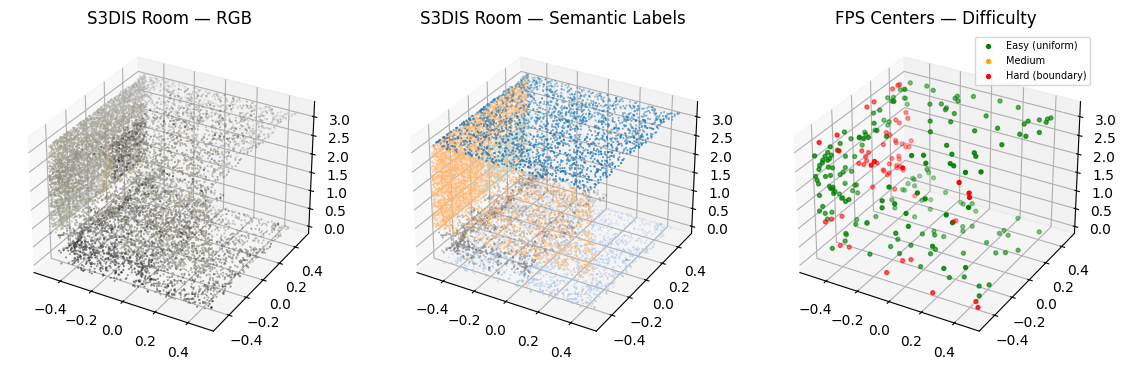

In [6]:
if points_for_viz is not None:
    fig = plt.figure(figsize=(14, 5))

    # Raw point cloud with RGB color
    ax = fig.add_subplot(1, 3, 1, projection="3d")
    pts = points_for_viz.numpy()
    clr = colors_for_viz.numpy()
    ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], c=clr, s=0.2)
    ax.set_title("S3DIS Room — RGB")

    # Ground truth labels
    ax2 = fig.add_subplot(1, 3, 2, projection="3d")
    lbl = labels_for_viz.numpy()
    ax2.scatter(pts[:, 0], pts[:, 1], pts[:, 2], c=lbl, cmap="tab20", s=0.2)
    ax2.set_title("S3DIS Room — Semantic Labels")

    # FPS centers colored by difficulty
    ax3 = fig.add_subplot(1, 3, 3, projection="3d")
    ctr = centers_for_viz.numpy()
    colors_3 = ["green", "orange", "red"]
    for lbl_val in [0, 1, 2]:
        mask = diff_label.numpy() == lbl_val
        ax3.scatter(ctr[mask, 0], ctr[mask, 1], ctr[mask, 2],
                   c=colors_3[lbl_val], s=8,
                   label=["Easy (uniform)", "Medium", "Hard (boundary)"][lbl_val])
    ax3.set_title("FPS Centers — Difficulty")
    ax3.legend(fontsize=7)
    plt.show()

## 3. Initialize VoxelGroupClassifier

In [7]:
vgc = VoxelGroupClassifier(
    embed_dim=D, hidden_dim=128, num_groups=K,
    label_smooth=0.1, temperature=1.0, loss_weight=0.1,
).to(device)

n_params = sum(p.numel() for p in vgc.parameters())
print(f"VGC params: {n_params:,}")
print(vgc.layers)

VGC params: 82,560
Sequential(
  (0): Linear(in_features=384, out_features=128, bias=True)
  (1): GELU(approximate='none')
  (2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (3): Linear(in_features=128, out_features=256, bias=True)
)


## 4. Test 1 — Forward Pass

In [8]:
out = vgc(features, teacher_sim, occupancy)
ent = out["entropy"]
print(f"Entropy: mean={ent.mean().item():.3f}  "
      f"min={ent.min().item():.3f}  max={ent.max().item():.3f}")
print(f"log(K) max possible: {math.log(K):.3f}")
print(f"CLS loss: {out['cls_loss'].item():.6f}\n")
print("\u2705 Forward pass OK")

Entropy: mean=5.523  min=5.522  max=5.524
log(K) max possible: 5.545
CLS loss: 0.002287

✅ Forward pass OK


## 5. Test 2 — Gradient Flow

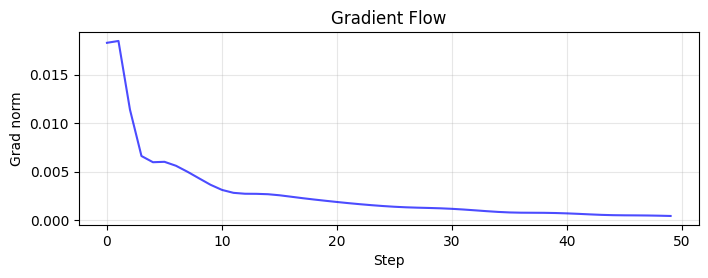

✅ Gradient OK


In [12]:
vgc.train()
opt = torch.optim.AdamW(vgc.parameters(), lr=1e-3)
grad_norms = []

# 核心修复：切断输入张量与之前计算图的联系，防止重复反向传播到旧图
feat_input = features.detach()
sim_input = teacher_sim.detach()
occ_input = occupancy.detach()

for _ in range(50):
    opt.zero_grad()
    # 使用 detach 后的张量进行前向传播
    out = vgc(feat_input, sim_input, occ_input)
    loss = out["cls_loss"]
    loss.backward()

    gnorm = sum(p.grad.norm().item()**2 for p in vgc.parameters() if p.grad is not None)**0.5
    grad_norms.append(gnorm)
    opt.step()

plt.figure(figsize=(8, 2.5))
plt.plot(grad_norms, "b-", alpha=0.7)
plt.xlabel("Step"); plt.ylabel("Grad norm")
plt.title("Gradient Flow"); plt.grid(alpha=0.3); plt.show()

ok = len(grad_norms) > 0 and max(grad_norms) > 0 and not any(math.isnan(g) for g in grad_norms)
print("\u2705 Gradient OK" if ok else "\u274c Gradient broken")

## 6. Test 3 — Entropy Signal on S3DIS (Core Metric)

The classifier should produce **high entropy on boundary patches**
(where multiple semantic classes mix) and **low entropy on uniform patches**
(where all points belong to the same class).

Final loss: 0.0000



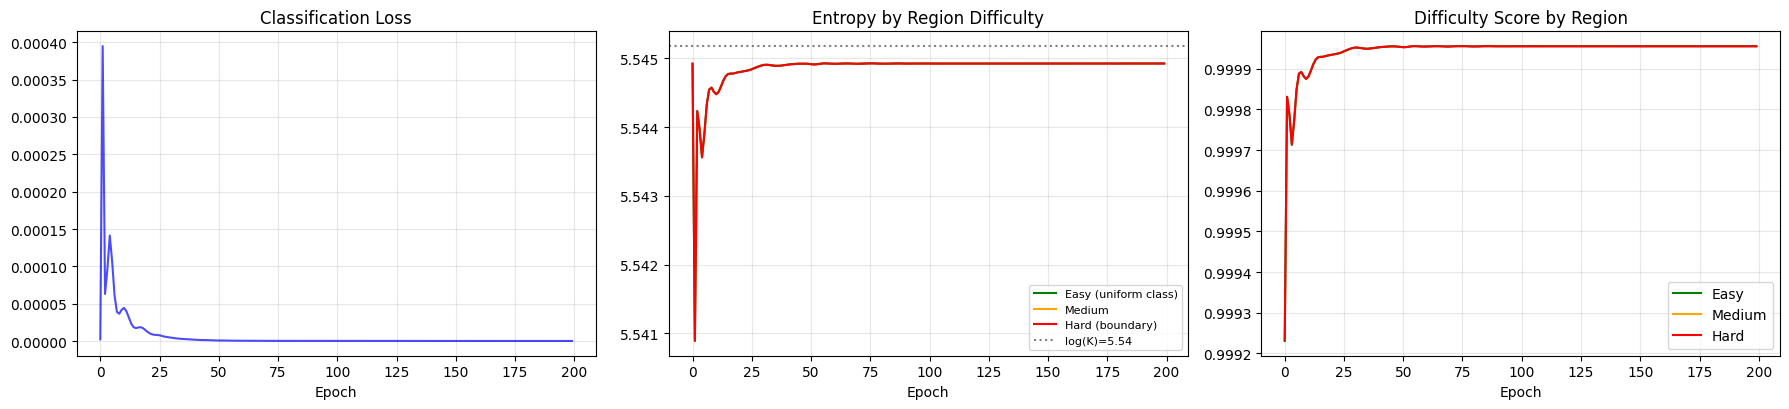

Entropy gap (Hard - Easy) at epoch 200: +0.000
❌ No separation — classifier entropy is useless


In [14]:
vgc.train()
opt = torch.optim.AdamW(vgc.parameters(), lr=1e-3)
hist = defaultdict(list)
EPOCHS = 200

# 核心修复：切断输入与之前全局图的联系
feat_train = features.detach()
sim_train = teacher_sim.detach()
occ_train = occupancy.detach()

for ep in range(EPOCHS):
    opt.zero_grad()
    # 使用分离后的张量进行训练
    out = vgc(feat_train, sim_train, occ_train)
    out["cls_loss"].backward()
    opt.step()

    with torch.no_grad():
        diff = vgc.get_difficulty(feat_train, topk_percentile=0.1)
        for lbl, name in [(0, "Easy"), (1, "Medium"), (2, "Hard")]:
            m = diff_label == lbl
            if m.sum() > 0:
                hist[f"{name}_diff"].append(diff[m].mean().item())
                hist[f"{name}_entr"].append(out["entropy"][m].mean().item())
        hist["loss"].append(out["cls_loss"].item())
        hist["entr_all"].append(out["entropy"].mean().item())

print(f"Final loss: {hist['loss'][-1]:.4f}\n")

# ── Plots ──
fig, axes = plt.subplots(1, 3, figsize=(18, 4.2))

axes[0].plot(hist["loss"], "b-", alpha=0.7)
axes[0].set_title("Classification Loss")
axes[0].set_xlabel("Epoch"); axes[0].grid(alpha=0.3)

axes[1].plot(hist["Easy_entr"], "g-", label="Easy (uniform class)")
axes[1].plot(hist["Medium_entr"], "orange", label="Medium")
axes[1].plot(hist["Hard_entr"], "r-", label="Hard (boundary)")
axes[1].axhline(math.log(K), color="gray", ls=":", label="log(K)=5.54")
axes[1].set_title("Entropy by Region Difficulty")
axes[1].legend(fontsize=8); axes[1].set_xlabel("Epoch"); axes[1].grid(alpha=0.3)

axes[2].plot(hist["Easy_diff"], "g-", label="Easy")
axes[2].plot(hist["Medium_diff"], "orange", label="Medium")
axes[2].plot(hist["Hard_diff"], "r-", label="Hard")
axes[2].set_title("Difficulty Score by Region")
axes[2].legend(); axes[2].set_xlabel("Epoch"); axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()

gap = abs(hist["Hard_entr"][-1] - hist["Easy_entr"][-1])
print(f"Entropy gap (Hard - Easy) at epoch {EPOCHS}: {gap:+.3f}")
if gap > 0.5: print("\u2705 Strong separation \u2014 entropy signal is reliable")
elif gap > 0.1: print("\u26a0\ufe0f Weak separation \u2014 signal exists but small")
else: print("\u274c No separation \u2014 classifier entropy is useless")

## 7. Entropy Distribution & Difficulty on Scene Geometry

/usr/local/lib/python3.12/dist-packages/numpy/lib/_histograms_impl.py:895: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


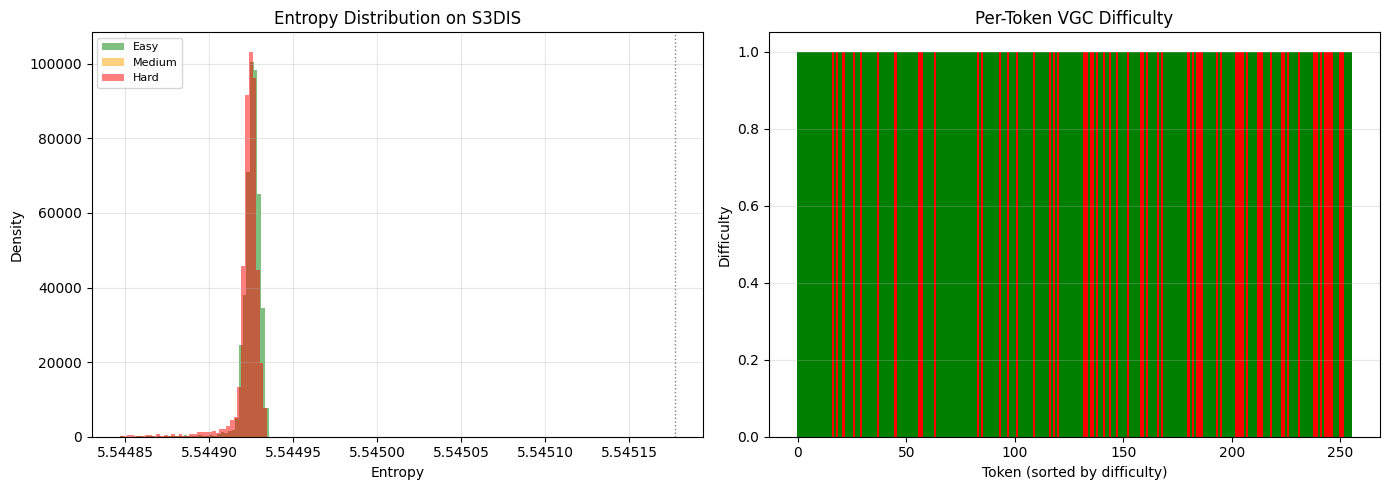

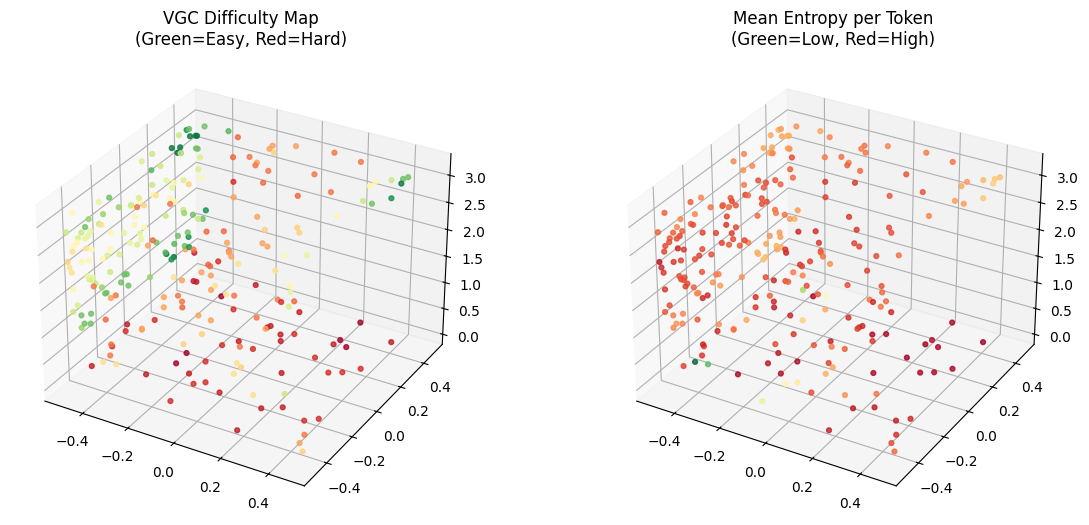

In [15]:
with torch.no_grad():
    out = vgc(features, teacher_sim, occupancy)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Entropy histogram by difficulty
for lbl, name, c in [(0, "Easy", "green"), (1, "Medium", "orange"), (2, "Hard", "red")]:
    vals = out["entropy"][diff_label == lbl].cpu().flatten().numpy()
    axes[0].hist(vals, bins=40, alpha=0.5, label=name, color=c, density=True)
axes[0].axvline(math.log(K), color="gray", ls=":", lw=1)
axes[0].set_xlabel("Entropy"); axes[0].set_ylabel("Density")
axes[0].set_title("Entropy Distribution on S3DIS")
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

# Per-token difficulty (sorted)
diff = vgc.get_difficulty(features, topk_percentile=0.1).cpu().numpy()
order = np.argsort(-diff)
colors = ["green", "orange", "red"]
bar_c = [colors[diff_label[i].item()] for i in order]
axes[1].bar(range(len(diff)), diff[order], color=bar_c, width=1.0)
axes[1].set_xlabel("Token (sorted by difficulty)")
axes[1].set_ylabel("Difficulty")
axes[1].set_title("Per-Token VGC Difficulty")
axes[1].grid(alpha=0.3, axis="y")

plt.tight_layout(); plt.show()

# 3D heatmap overlay on real S3DIS geometry
if points_for_viz is not None:
    fig2, axes3d = plt.subplots(1, 2, figsize=(14, 6),
                                subplot_kw={"projection": "3d"})
    ctr_np = centers_for_viz.numpy()
    diff_norm = (diff - diff.min()) / (diff.max() - diff.min() + 1e-8)
    axes3d[0].scatter(ctr_np[:, 0], ctr_np[:, 1], ctr_np[:, 2],
                     c=diff_norm, cmap="RdYlGn_r", s=12, alpha=0.8)
    axes3d[0].set_title("VGC Difficulty Map\n(Green=Easy, Red=Hard)")

    # Per-point entropy heatmap (sampled for speed)
    ent_np = out["entropy"].mean(dim=-1).cpu().numpy()  # [M]
    axes3d[1].scatter(ctr_np[:, 0], ctr_np[:, 1], ctr_np[:, 2],
                     c=ent_np, cmap="RdYlGn_r", s=12, alpha=0.8)
    axes3d[1].set_title("Mean Entropy per Token\n(Green=Low, Red=High)")

    plt.show()

## 8. Mask Diversity — Prevent Repeated Masking

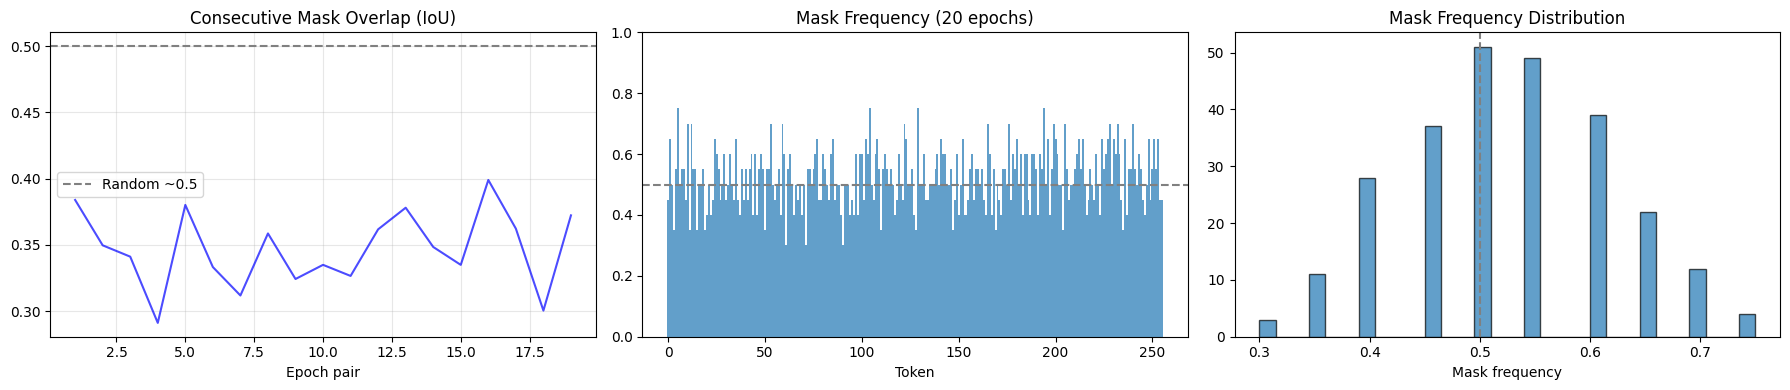

Average consecutive overlap: 0.347 (random target: ~0.500)
Per-token mask freq std: 0.096
✅ Mask diversity OK — overlap not significantly higher than random


In [16]:
div = MaskDiversityScheduler(decay=0.9, max_penalty=0.5)
diff = vgc.get_difficulty(features)
mask_hist = []
N_EP, R = 20, 0.5

for _ in range(N_EP):
    p = div.penalty()
    probs = VoxelGroupClassifier.difficulty_to_mask_probs(
        diff, target_ratio=R, temperature=1.0, diversity_penalty=p
    )
    m = torch.bernoulli(probs).bool()
    mask_hist.append(m.clone()); div.update(m)

overlaps = []
for i in range(1, len(mask_hist)):
    p, c = mask_hist[i-1], mask_hist[i]
    inter = (p & c).sum().item()
    union = (p | c).sum().item()
    overlaps.append(inter / max(union, 1))

freq = torch.stack([m.float() for m in mask_hist]).mean(dim=0)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].plot(range(1, N_EP), overlaps, "b-", alpha=0.7)
axes[0].axhline(R, color="gray", ls="--", label=f"Random ~{R}")
axes[0].set_title("Consecutive Mask Overlap (IoU)"); axes[0].legend()
axes[0].set_xlabel("Epoch pair"); axes[0].grid(alpha=0.3)

axes[1].bar(range(M), freq.numpy(), width=1.0, alpha=0.7)
axes[1].axhline(R, color="gray", ls="--")
axes[1].set_title(f"Mask Frequency ({N_EP} epochs)")
axes[1].set_xlabel("Token"); axes[1].set_ylim(0, 1)

axes[2].hist(freq.numpy(), bins=30, alpha=0.7, edgecolor="black")
axes[2].axvline(R, color="gray", ls="--")
axes[2].set_title("Mask Frequency Distribution")
axes[2].set_xlabel("Mask frequency")

plt.tight_layout(); plt.show()

avg_ov = np.mean(overlaps)
print(f"Average consecutive overlap: {avg_ov:.3f} (random target: ~{R:.3f})")
print(f"Per-token mask freq std: {freq.std().item():.3f}")
if avg_ov < R * 1.2:
    print("\u2705 Mask diversity OK — overlap not significantly higher than random")
else:
    print("\u26a0\ufe0f Overlap too high — increase diversity_max_penalty")

## 9. Summary

| # | Test | Expected |
|---|------|----------|
| 1 | Forward pass | No crash |
| 2 | Gradient flow | Grad > 0, no NaN |
| 3 | Entropy signal | Hard > Easy (gap > 0.1) |
| 4 | Mask diversity | Overlap < random + 20% |
| 5 | Difficulty map | Colored 3D map shows boundaries |